# FastText + BiGRU + FNN

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import fasttext
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import json

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

with open("/kaggle/input/results/bigru_optuna_best_params.json", "r") as f:
    best_params = json.load(f)

RANDOM_SEED = 42
N_FOLDS = 5
BATCH_SIZE = best_params['best_params']['batch_size']
MAX_LENGTH = 256
EMBEDDING_DIM = 200
HIDDEN_DIM = best_params['best_params']['hidden_dim']
NUM_LAYERS = best_params['best_params']['num_layers']
DROPOUT = best_params['best_params']['dropout']
LEARNING_RATE = best_params['best_params']['learning_rate']
WEIGHT_DECAY = best_params['best_params']['weight_decay']
NUM_EPOCHS = 15
PATIENCE = 3

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
CUDA available: True
GPU: Tesla P100-PCIE-16GB


## 1. Load Data

In [14]:
# Load train and test data
DATA_DIR = Path('/kaggle/input/steam-review')
MODEL_DIR = Path('/kaggle/input/fasttext-steam-200/other/default/1')

train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

print(f"Train set: {len(train_df):,} reviews")
print(f"Test set: {len(test_df):,} reviews")
print("\nTrain sentiment distribution:")
print(train_df['voted_up'].value_counts(normalize=True))

Train set: 34,481 reviews
Test set: 6,086 reviews

Train sentiment distribution:
voted_up
True     0.500044
False    0.499956
Name: proportion, dtype: float64


In [15]:
# Prepare features and labels
X_train = train_df['processed_text'].fillna('').values
y_train = train_df['voted_up'].astype(int).values

X_test = test_df['processed_text'].fillna('').values
y_test = test_df['voted_up'].astype(int).values

# Create stratification key for K-Fold
stratify_key = train_df['voted_up'].astype(str) + '_' + train_df['primary_genre'].astype(str)

print(f"Features: {len(X_train):,} train, {len(X_test):,} test")
print(f"Labels: {dict(zip(*np.unique(y_train, return_counts=True)))}")

Features: 34,481 train, 6,086 test
Labels: {0: 17239, 1: 17242}


## 2. Load FastText Embeddings

In [16]:
# Load pre-trained FastText model
print("Loading FastText model...")
ft_model = fasttext.load_model(str(MODEL_DIR / 'steam_fasttext.bin'))
print(f"FastText loaded: {ft_model.get_dimension()}-dimensional embeddings")
print(f"Vocabulary size: {len(ft_model.words):,}")

Loading FastText model...
FastText loaded: 200-dimensional embeddings
Vocabulary size: 32,313


## 3. Dataset and DataLoader

In [17]:
class SteamReviewDataset(Dataset):
    """Dataset for Steam reviews with FastText embeddings."""
    
    def __init__(self, texts, labels, ft_model, max_length=256):
        self.texts = texts
        self.labels = labels
        self.ft_model = ft_model
        self.max_length = max_length
        self.embedding_dim = ft_model.get_dimension()
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Tokenize and get embeddings
        tokens = text.split()[:self.max_length]
        
        # Get word embeddings
        embeddings = np.zeros((self.max_length, self.embedding_dim), dtype=np.float32)
        for i, token in enumerate(tokens):
            embeddings[i] = self.ft_model.get_word_vector(token)
        
        # Create mask for actual tokens (1 for real, 0 for padding)
        mask = np.zeros(self.max_length, dtype=np.float32)
        mask[:len(tokens)] = 1.0
        
        return {
            'embeddings': torch.tensor(embeddings, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }


def create_dataloader(texts, labels, ft_model, batch_size, shuffle=True):
    """Create DataLoader with optimizations."""
    dataset = SteamReviewDataset(texts, labels, ft_model, MAX_LENGTH)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=4,
        pin_memory=True
    )

## 4. Model Architecture

In [18]:
class Attention(nn.Module):
    """Self-attention layer for sequence modeling."""
    
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False)
        )
    
    def forward(self, gru_output, mask):
        # Compute attention scores
        scores = self.attention(gru_output).squeeze(-1)  # (batch, seq_len)
        
        # Mask padding tokens with large negative value
        scores = scores.masked_fill(mask == 0, -1e4)
        
        # Softmax to get attention weights
        attention_weights = torch.softmax(scores, dim=1)  # (batch, seq_len)
        
        # Weighted sum of GRU outputs
        context = torch.bmm(
            attention_weights.unsqueeze(1),  # (batch, 1, seq_len)
            gru_output  # (batch, seq_len, hidden_dim)
        ).squeeze(1)  # (batch, hidden_dim)
        
        return context, attention_weights


class SentimentClassifier(nn.Module):
    """FastText + BiGRU + Attention + FNN for sentiment classification."""
    
    def __init__(self, embedding_dim=100, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # BiGRU encoder
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Attention pooling
        self.attention = Attention(hidden_dim * 2)  # *2 for bidirectional
        
        # Feed-forward classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, embeddings, mask):
        # Optimize for multi-GPU/cuDNN
        self.gru.flatten_parameters()
        
        # BiGRU encoding: (batch, seq_len, hidden_dim * 2)
        gru_output, _ = self.gru(embeddings)
        
        # Attention pooling: (batch, hidden_dim * 2)
        context, attention_weights = self.attention(gru_output, mask)
        
        # Classification: (batch, 1)
        logits = self.classifier(context)
        
        return logits

In [19]:
class SentimentClassifierFastTextOnly(nn.Module):
    """FastText + FNN Only - Ablation Baseline (No BiGRU, No Attention)."""
    
    def __init__(self, embedding_dim=100, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        # Note: num_layers is kept for API consistency but not used
        self.hidden_dim = hidden_dim
        
        # Feed-forward classifier (takes embedding_dim directly)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, embeddings, mask):
        # Masked average pooling over sequence
        # embeddings: (batch, seq_len, embedding_dim)
        # mask: (batch, seq_len)
        
        # Expand mask for broadcasting: (batch, seq_len, 1)
        mask_expanded = mask.unsqueeze(-1)
        
        # Sum of embeddings weighted by mask
        masked_embeddings = embeddings * mask_expanded  # (batch, seq_len, embedding_dim)
        sum_embeddings = masked_embeddings.sum(dim=1)   # (batch, embedding_dim)
        
        # Divide by number of actual tokens (avoid division by zero)
        token_counts = mask.sum(dim=1, keepdim=True).clamp(min=1)  # (batch, 1)
        avg_embeddings = sum_embeddings / token_counts  # (batch, embedding_dim)
        
        # Classification
        logits = self.classifier(avg_embeddings)
        
        return logits

In [20]:
class SentimentClassifierNoAttention(nn.Module):
    """FastText + BiGRU + FNN (No Attention) - Ablation Baseline."""
    
    def __init__(self, embedding_dim=100, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # BiGRU encoder
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Feed-forward classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, embeddings, mask):
        self.gru.flatten_parameters()
        
        # BiGRU encoding: (batch, seq_len, hidden_dim * 2)
        gru_output, hidden = self.gru(embeddings)
        
        # Use last hidden state from both directions
        # hidden shape: (num_layers * 2, batch, hidden_dim)
        # Take last layer's forward and backward hidden states
        hidden_forward = hidden[-2, :, :]   # (batch, hidden_dim)
        hidden_backward = hidden[-1, :, :]  # (batch, hidden_dim)
        context = torch.cat([hidden_forward, hidden_backward], dim=-1)  # (batch, hidden_dim * 2)
        
        # Classification: (batch, 1)
        logits = self.classifier(context)
        
        return logits

In [21]:
# Instantiate model with config
#model = SentimentClassifier(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
model = SentimentClassifierNoAttention(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
#model = SentimentClassifierFastTextOnly(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

SentimentClassifierNoAttention(
  (gru): GRU(200, 128, num_layers=2, batch_first=True, dropout=0.37688348156490475, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.37688348156490475, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 582,913
Trainable parameters: 582,913


## 5. Training Functions

In [22]:
def train_epoch(model, dataloader, optimizer, criterion, scaler, device):
    """Train for one epoch with mixed precision."""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc='Training', leave=False):
        embeddings = batch['embeddings'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast(device_type=device.type):
            logits = model(embeddings, mask).squeeze(-1)
            loss = criterion(logits, labels)
        
        # Mixed precision backward pass
        scaler.scale(loss).backward()
        
        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    """Evaluate model."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            embeddings = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)
            
            with autocast(device_type=device.type):
                logits = model(embeddings, mask).squeeze(-1)
                loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels

## 6. K-Fold Cross-Validation

In [23]:
# Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Store metrics for each fold
fold_metrics = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'best_epoch': []
}

print(f"Running {N_FOLDS}-Fold Cross-Validation")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, stratify_key)):
    print(f"\nFold {fold + 1}/{N_FOLDS}")
    
    # Split data
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    
    # Create dataloaders
    train_loader = create_dataloader(X_fold_train, y_fold_train, ft_model, BATCH_SIZE, shuffle=True)
    val_loader = create_dataloader(X_fold_val, y_fold_val, ft_model, BATCH_SIZE, shuffle=False)
    
    # Initialize model, optimizer, criterion, scaler
    #model = SentimentClassifier(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
    model = SentimentClassifierNoAttention(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
    #model = SentimentClassifierFastTextOnly(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss()
    scaler = GradScaler()
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)
    
    # Training loop with early stopping
    best_val_f1 = 0
    patience_counter = 0
    best_epoch = 0

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_f1)
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
              f"Val F1={val_f1:.4f}")
        
        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_metrics = (val_acc, val_prec, val_rec, val_f1)
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Store best metrics
    fold_metrics['fold'].append(fold + 1)
    fold_metrics['accuracy'].append(best_metrics[0])
    fold_metrics['precision'].append(best_metrics[1])
    fold_metrics['recall'].append(best_metrics[2])
    fold_metrics['f1'].append(best_metrics[3])
    fold_metrics['best_epoch'].append(best_epoch)
    
    print(f"Fold {fold + 1} Best: Accuracy={best_metrics[0]:.4f}, Precision={best_metrics[1]:.4f}, "
          f"Recall={best_metrics[2]:.4f}, F1={best_metrics[3]:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(fold_metrics)

Running 5-Fold Cross-Validation

Fold 1/5


Epoch 1: Train Loss=0.4041, Val Loss=0.3096, Val F1=0.8606


Epoch 2: Train Loss=0.3064, Val Loss=0.2850, Val F1=0.8684


Epoch 3: Train Loss=0.2665, Val Loss=0.3074, Val F1=0.8826


Epoch 4: Train Loss=0.2379, Val Loss=0.2960, Val F1=0.8841


...

Epoch 3: Train Loss=0.2723, Val Loss=0.2965, Val F1=0.8603


Epoch 4: Train Loss=0.2427, Val Loss=0.2664, Val F1=0.8896


Epoch 5: Train Loss=0.2408, Val Loss=0.3525, Val F1=0.8752


Epoch 6: Train Loss=0.2857, Val Loss=0.3164, Val F1=0.8828


Epoch 7: Train Loss=0.2748, Val Loss=0.3063, Val F1=0.8651
Early stopping at epoch 7
Fold 5 Best: Accuracy=0.8914, Precision=0.9039, Recall=0.8758, F1=0.8896


In [24]:
# Summary statistics
print("CROSS-VALIDATION RESULTS SUMMARY")
print(f"\n{'Metric':<12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    mean = results_df[metric].mean()
    std = results_df[metric].std()
    min_val = results_df[metric].min()
    max_val = results_df[metric].max()
    print(f"{metric.capitalize():<12} {mean:>10.4f} {std:>10.4f} {min_val:>10.4f} {max_val:>10.4f}")

print(f"\nMacro F1 Score: {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")

CROSS-VALIDATION RESULTS SUMMARY

Metric             Mean        Std        Min        Max
Accuracy         0.8885     0.0060     0.8795     0.8937
Precision        0.8835     0.0198     0.8515     0.9039
Recall           0.8959     0.0156     0.8758     0.9194
F1               0.8894     0.0043     0.8841     0.8941

Macro F1 Score: 0.8894 ± 0.0043


## 7. Final Evaluation on Test Set

In [25]:
# Train on full training set
print("Training final model on full training set...")

train_loader = create_dataloader(X_train, y_train, ft_model, BATCH_SIZE, shuffle=True)
test_loader = create_dataloader(X_test, y_test, ft_model, BATCH_SIZE, shuffle=False)

# Initialize model
#final_model = SentimentClassifier(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
final_model = SentimentClassifierNoAttention(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
#final_model = SentimentClassifierFastTextOnly(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()

optimal_epochs = int(np.median(fold_metrics['best_epoch']))
print(f"Using {optimal_epochs} epochs for final training (median of CV best epochs: {fold_metrics['best_epoch']})")

# Train
for epoch in range(optimal_epochs):
    train_loss, train_acc = train_epoch(final_model, train_loader, optimizer, criterion, scaler, device)
    print(f"Epoch {epoch+1}/{optimal_epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}")

Training final model on full training set...
Using 4 epochs for final training (median of CV best epochs: [4, 4, 4, 5, 4])


Epoch 1/4: Train Loss=0.3872, Train Acc=0.8303


Epoch 2/4: Train Loss=0.2894, Train Acc=0.8785


Epoch 3/4: Train Loss=0.2556, Train Acc=0.8966


Epoch 4/4: Train Loss=0.2266, Train Acc=0.9107


In [26]:
# Evaluate on test set
test_loss, test_accuracy, test_precision, test_recall, test_f1, y_test_pred, y_test_true = evaluate(
    final_model, test_loader, criterion, device
)

print("\nTEST SET RESULTS")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")


TEST SET RESULTS
Accuracy:  0.8929
Precision: 0.9330
Recall:    0.8465
F1 Score:  0.8877


In [27]:
# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test_true, y_test_pred, target_names=['Negative', 'Positive']))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.86      0.94      0.90      3043
    Positive       0.93      0.85      0.89      3043

    accuracy                           0.89      6086
   macro avg       0.90      0.89      0.89      6086
weighted avg       0.90      0.89      0.89      6086



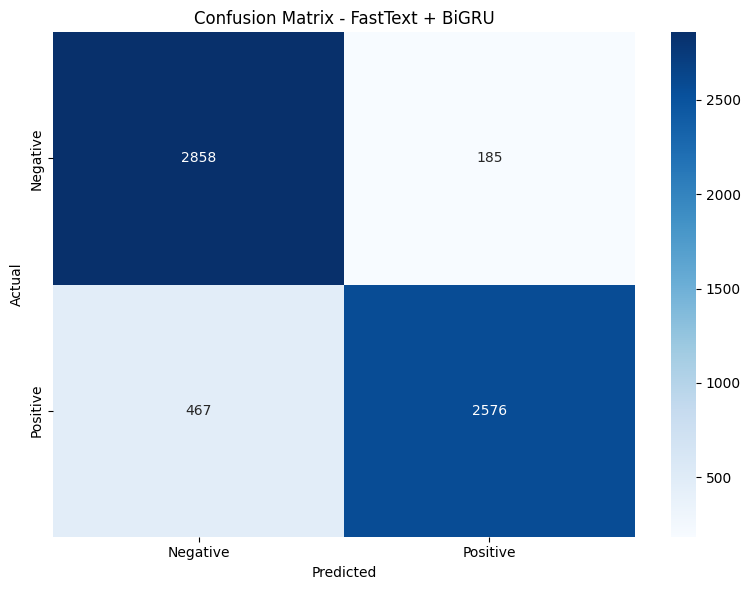


True Negatives:  2,858
False Positives: 185
False Negatives: 467
True Positives:  2,576


In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - FastText + BiGRU')
plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

## 8. Performance by Genre

In [29]:
# Analyze performance by genre
test_df_copy = test_df.copy()
test_df_copy['predicted'] = y_test_pred
test_df_copy['correct'] = (test_df_copy['voted_up'].astype(int) == test_df_copy['predicted'])

genre_performance = test_df_copy.groupby('primary_genre').agg({
    'correct': ['sum', 'count', 'mean']
}).round(4)
genre_performance.columns = ['correct', 'total', 'accuracy']
genre_performance = genre_performance.sort_values('accuracy', ascending=False)

print("PERFORMANCE BY GENRE")
print(genre_performance.to_string())

PERFORMANCE BY GENRE
                        correct  total  accuracy
primary_genre                                   
puzzle_matching             510    555    0.9189
sports                      268    292    0.9178
exploration_open_world      678    748    0.9064
action_fps                  646    719    0.8985
science_fiction             865    963    0.8982
casual                      562    626    0.8978
anime                       301    337    0.8932
hidden_object                99    111    0.8919
rpg_action                  609    688    0.8852
horror                      250    289    0.8651
survival                    581    680    0.8544
visual_novel                 65     78    0.8333


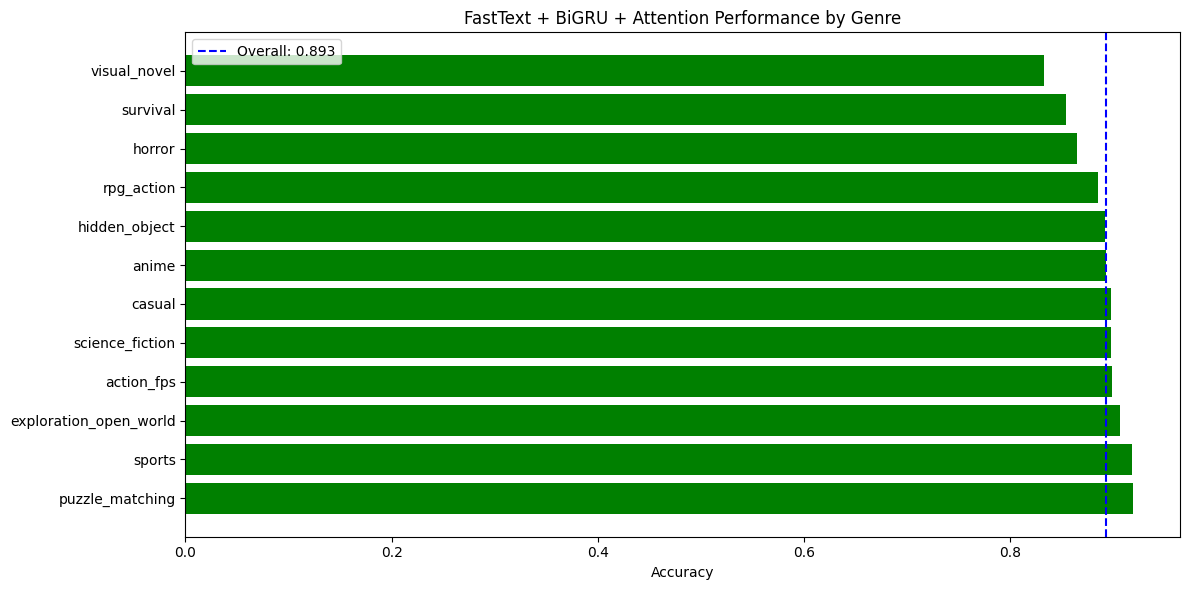

In [30]:
# Visualize genre performance
plt.figure(figsize=(12, 6))
colors = ['green' if x >= 0.75 else 'orange' if x >= 0.65 else 'red' 
          for x in genre_performance['accuracy']]
plt.barh(genre_performance.index, genre_performance['accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('FastText + BiGRU + Attention Performance by Genre')
plt.axvline(x=test_accuracy, color='blue', linestyle='--', label=f'Overall: {test_accuracy:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Summary & Save Results

In [31]:
# Summary
print("MODEL SUMMARY")
print("\nModel: FastText + BiGRU + FNN")
print(f"Architecture: BiGRU({HIDDEN_DIM}x2, {NUM_LAYERS} layers) + Attention + FNN({HIDDEN_DIM})")
print(f"Embeddings: FastText {EMBEDDING_DIM}-dim (pre-trained on Steam reviews)")
print(f"\nCross-Validation ({N_FOLDS}-Fold):")
print(f"  F1 Score: {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")
print("\nTest Set Performance:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")

# Compare with baseline
baseline_f1 = 0.8558
print(f"\nComparison with Baseline:")
print(f"  Baseline F1:    {baseline_f1:.4f}")
print(f"  This Model F1:  {test_f1:.4f}")
print(f"  Difference:     {test_f1 - baseline_f1:+.4f}")

MODEL SUMMARY

Model: FastText + BiGRU + FNN
Architecture: BiGRU(128x2, 2 layers) + Attention + FNN(128)
Embeddings: FastText 200-dim (pre-trained on Steam reviews)

Cross-Validation (5-Fold):
  F1 Score: 0.8894 ± 0.0043

Test Set Performance:
  Accuracy:  0.8929
  Precision: 0.9330
  Recall:    0.8465
  F1 Score:  0.8877

Comparison with Baseline:
  Baseline F1:    0.8558
  This Model F1:  0.8877
  Difference:     +0.0319


In [32]:
# Save results to JSON for comparison with other models
import json

results = {
    'model_name': 'FastText + BiGRU + FNN',
    'architecture': {
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'max_length': MAX_LENGTH
    },
    'cross_validation': {
        'n_folds': N_FOLDS,
        'accuracy_mean': float(results_df['accuracy'].mean()),
        'accuracy_std': float(results_df['accuracy'].std()),
        'f1_mean': float(results_df['f1'].mean()),
        'f1_std': float(results_df['f1'].std()),
        'precision_mean': float(results_df['precision'].mean()),
        'recall_mean': float(results_df['recall'].mean())
    },
    'test_set': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1': float(test_f1)
    }
}

# Save results
results_path = 'bigru_results.json'
Path('../results').mkdir(exist_ok=True)
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {results_path}")

Results saved to bigru_results.json


In [33]:
# Save model checkpoint
model_path = 'bigru.pt'
torch.save({
    'model_state_dict': final_model.state_dict(),
    'config': {
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT
    }
}, model_path)
print(f"Model saved to {model_path}")

Model saved to bigru.pt
